# 02 Baseline、回测与提交文件生成

这个 Notebook 接在 `01_任务理解_数据探索_清洗框架.ipynb` 后面，目标更聚焦：

1. 按官方口径重新构造 A/B 训练标签。
2. 搭建多个简单 baseline。
3. 用训练期内部 rolling backtest 比较方法稳定性。
4. 用最佳或较稳策略预测 2018-01-25 到 2018-01-31。
5. 生成 A/B 两个提交 CSV。

原则：先把强 baseline 做扎实，再考虑复杂模型。

## 0. 环境、路径和工具函数

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

REGION_ORDER = ["core", "near", "outer"]
REGION_CN = {
    "core": "核心区",
    "near": "近港区",
    "outer": "外围区",
}
PAIRS = [(s, t) for s in REGION_ORDER for t in REGION_ORDER if s != t]

CENTER_LON = 117.79
CENTER_LAT = 38.97
KM_PER_LAT = 111.32
KM_PER_LON = 111.32 * math.cos(math.radians(CENTER_LAT))


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents, Path(r"C:\Users\mandy\hl_Documents\2026CTS")]
    seen = set()
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "notebooks").exists() or (candidate / "PLAN.md").exists() or (candidate / "Clippings").exists():
            return candidate
    raise FileNotFoundError("找不到项目根目录")


def find_data_files(root: Path) -> tuple[Path, Path]:
    csv_files = [p for p in root.rglob("*.csv") if p.is_file()]
    if not csv_files:
        raise FileNotFoundError(f"在项目目录中找不到 CSV 文件: {root}")
    csv_files = sorted(csv_files, key=lambda p: p.stat().st_size, reverse=True)
    train_path = csv_files[0]
    val_candidates = [p for p in csv_files[1:] if p.stat().st_size < 100_000]
    if not val_candidates:
        raise FileNotFoundError("找不到验证每日船数 CSV")
    return train_path, val_candidates[0]

ROOT = find_project_root(Path.cwd())
TRAIN_PATH, VAL_DAILY_PATH = find_data_files(ROOT)
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
TEMPLATE_DIR = OUTPUT_DIR / "_official_examples_backup"
TEMPLATE_DIR.mkdir(exist_ok=True)
RUN_STAMP = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
RUN_OUTPUT_DIR = OUTPUT_DIR / RUN_STAMP
RUN_OUTPUT_DIR.mkdir(exist_ok=True)

print("项目根目录:", ROOT)
print("训练集:", TRAIN_PATH, round(TRAIN_PATH.stat().st_size / 1024 / 1024, 2), "MB")
print("验证每日船数:", VAL_DAILY_PATH, VAL_DAILY_PATH.stat().st_size, "B")
print("输出目录:", OUTPUT_DIR)
print("官方模板备份目录:", TEMPLATE_DIR)
print("本次运行输出目录:", RUN_OUTPUT_DIR)

项目根目录: C:\Users\mandy\hl_Documents\2026CTS
训练集: C:\Users\mandy\hl_Documents\2026CTS\notebooks\训练集_20180101-0124_拖轮AIS\训练集_20180101-0124_拖轮AIS.csv 229.17 MB
验证每日船数: C:\Users\mandy\hl_Documents\2026CTS\outputs\a_train_labels.csv 93979 B
输出目录: C:\Users\mandy\hl_Documents\2026CTS\outputs
官方模板备份目录: C:\Users\mandy\hl_Documents\2026CTS\outputs\_official_examples_backup
本次运行输出目录: C:\Users\mandy\hl_Documents\2026CTS\outputs\20260709_110148


## 1. 读取数据并构造圈层

In [2]:
usecols = ["mmsi", "x", "y", "sog", "time"]
dtypes = {
    "mmsi": "string",
    "x": "float64",
    "y": "float64",
    "sog": "float32",
}

df = pd.read_csv(TRAIN_PATH, usecols=usecols, dtype=dtypes, parse_dates=["time"])
df["hour"] = df["time"].dt.floor("h")
df["date"] = df["time"].dt.normalize()
df["hour_of_day"] = df["time"].dt.hour
df["dayofweek"] = df["time"].dt.dayofweek

dx = (df["x"] - CENTER_LON) * KM_PER_LON
dy = (df["y"] - CENTER_LAT) * KM_PER_LAT
df["dist_km"] = np.sqrt(dx * dx + dy * dy)
df["region"] = np.select(
    [df["dist_km"] < 3, df["dist_km"].between(3, 10, inclusive="left"), df["dist_km"].between(10, 30, inclusive="left")],
    ["core", "near", "outer"],
    default="outside",
)
df["region"] = pd.Categorical(df["region"], categories=["core", "near", "outer", "outside"], ordered=True)

val_daily = pd.read_csv(VAL_DAILY_PATH, parse_dates=["date"])
val_daily["date"] = val_daily["date"].dt.normalize()
train_daily = df.groupby("date")["mmsi"].nunique().rename("vessel_count").reset_index()

print("rows:", len(df))
print("time:", df["time"].min(), "->", df["time"].max())
print("unique mmsi:", df["mmsi"].nunique())
display(df["region"].value_counts().to_frame("points"))
display(train_daily.tail())
display(val_daily)

rows: 2039846
time: 2018-01-01 00:00:00 -> 2018-01-24 23:59:59
unique mmsi: 109


,points
region,
core,1132351
near,597639
outer,238836
outside,71020


,date,vessel_count
19,2018-01-20,55
20,2018-01-21,54
21,2018-01-22,52
22,2018-01-23,48
23,2018-01-24,48


,hour,region,y,task_key,date,hour_of_day,dayofweek,is_weekend,vessel_count
0,2018-01-01 00:00:00,core,2,core,2018-01-01,0,0,0,49
1,2018-01-01 00:00:00,near,0,near,2018-01-01,0,0,0,49
2,2018-01-01 00:00:00,outer,1,outer,2018-01-01,0,0,0,49
3,2018-01-01 01:00:00,core,0,core,2018-01-01,1,0,0,49
4,2018-01-01 01:00:00,near,2,near,2018-01-01,1,0,0,49
...,...,...,...,...,...,...,...,...,...
1723,2018-01-24 22:00:00,near,7,near,2018-01-24,22,2,0,48
1724,2018-01-24 22:00:00,outer,1,outer,2018-01-24,22,2,0,48
1725,2018-01-24 23:00:00,core,8,core,2018-01-24,23,2,0,48
1726,2018-01-24 23:00:00,near,6,near,2018-01-24,23,2,0,48


## 2. 构造官方 A/B 标签

In [3]:
def make_a_labels(data: pd.DataFrame) -> pd.DataFrame:
    active = data[data["region"].isin(REGION_ORDER) & data["sog"].between(2, 10, inclusive="both")]
    ship_region_counts = (
        active.groupby(["hour", "region", "mmsi"], observed=True)
        .size()
        .rename("ais_points")
        .reset_index()
    )
    qualified = ship_region_counts[ship_region_counts["ais_points"] >= 3]
    labels = (
        qualified.groupby(["hour", "region"], observed=True)["mmsi"]
        .nunique()
        .rename("y")
        .reset_index()
    )
    hours = pd.date_range(data["hour"].min(), data["hour"].max(), freq="h")
    full_index = pd.MultiIndex.from_product([hours, REGION_ORDER], names=["hour", "region"])
    labels = labels.set_index(["hour", "region"]).reindex(full_index, fill_value=0).reset_index()
    labels["region"] = labels["region"].astype(str)
    labels["task_key"] = labels["region"]
    return labels


def make_b_labels(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    in_region = data[data["region"].isin(REGION_ORDER)]
    agg = (
        in_region.groupby(["mmsi", "hour", "region"], observed=True)
        .agg(points=("time", "size"), last_time=("time", "max"))
        .reset_index()
    )
    representative = (
        agg.sort_values(["mmsi", "hour", "points", "last_time"], ascending=[True, True, False, False])
        .drop_duplicates(["mmsi", "hour"], keep="first")
        .sort_values(["mmsi", "hour"])
        .rename(columns={"region": "source_region"})
    )
    representative["next_hour"] = representative.groupby("mmsi")["hour"].shift(-1)
    representative["target_region"] = representative.groupby("mmsi")["source_region"].shift(-1)
    moved = representative[
        (representative["next_hour"] == representative["hour"] + pd.Timedelta(hours=1))
        & (representative["source_region"].astype(str) != representative["target_region"].astype(str))
    ]
    labels = (
        moved.groupby(["hour", "source_region", "target_region"], observed=True)["mmsi"]
        .nunique()
        .rename("y")
        .reset_index()
    )
    hours = pd.date_range(data["hour"].min(), data["hour"].max(), freq="h")
    full_index = pd.MultiIndex.from_tuples(
        [(h, s, t) for h in hours for s, t in PAIRS],
        names=["hour", "source_region", "target_region"],
    )
    labels = labels.set_index(["hour", "source_region", "target_region"]).reindex(full_index, fill_value=0).reset_index()
    labels["source_region"] = labels["source_region"].astype(str)
    labels["target_region"] = labels["target_region"].astype(str)
    labels["task_key"] = labels["source_region"] + "->" + labels["target_region"]
    return labels, representative


a_labels = make_a_labels(df)
b_labels, rep_region = make_b_labels(df)

print("A labels:", a_labels.shape)
print("B labels:", b_labels.shape)
display(a_labels.groupby("region")["y"].describe())
display(b_labels.groupby("task_key")["y"].describe())

A labels: (1728, 4)
B labels: (3456, 5)


,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
core,576.0,5.918403,4.311595,0.0,2.0,6.0,9.0,17.0
near,576.0,3.769097,3.074238,0.0,1.0,3.0,6.0,14.0
outer,576.0,1.758681,1.561191,0.0,1.0,1.0,3.0,9.0


,count,mean,std,min,25%,50%,75%,max
task_key,,,,,,,,
core->near,576.0,1.083333,1.470877,0.0,0.0,0.0,2.0,9.0
core->outer,576.0,0.215278,0.536179,0.0,0.0,0.0,0.0,3.0
near->core,576.0,1.098958,1.366277,0.0,0.0,1.0,2.0,9.0
near->outer,576.0,0.342014,0.745565,0.0,0.0,0.0,0.0,6.0
outer->core,576.0,0.185764,0.477536,0.0,0.0,0.0,0.0,3.0
outer->near,576.0,0.390625,0.749619,0.0,0.0,0.0,1.0,5.0


## 3. 统一特征：时间特征和每日船数

In [4]:
def add_time_features(frame: pd.DataFrame, daily_hint: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["date"] = out["hour"].dt.normalize()
    out["hour_of_day"] = out["hour"].dt.hour
    out["dayofweek"] = out["hour"].dt.dayofweek
    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)
    hint = daily_hint.copy()
    hint["date"] = pd.to_datetime(hint["date"]).dt.normalize()
    out = out.merge(hint[["date", "vessel_count"]], on="date", how="left")
    return out


a_frame = add_time_features(a_labels, train_daily)
b_frame = add_time_features(b_labels, train_daily)

print(a_frame.head().to_string(index=False))
print(b_frame.head().to_string(index=False))

               hour region  y task_key       date  hour_of_day  dayofweek  is_weekend  vessel_count
2018-01-01 00:00:00   core  2     core 2018-01-01            0          0           0            49
2018-01-01 00:00:00   near  0     near 2018-01-01            0          0           0            49
2018-01-01 00:00:00  outer  1    outer 2018-01-01            0          0           0            49
2018-01-01 01:00:00   core  0     core 2018-01-01            1          0           0            49
2018-01-01 01:00:00   near  2     near 2018-01-01            1          0           0            49
      hour source_region target_region  y    task_key       date  hour_of_day  dayofweek  is_weekend  vessel_count
2018-01-01          core          near  0  core->near 2018-01-01            0          0           0            49
2018-01-01          core         outer  0 core->outer 2018-01-01            0          0           0            49
2018-01-01          near          core  0  near->core 2

## 4. Baseline 方法

下面实现几类简单预测器：

- `global_mean`：每个区域/迁移方向的全训练期均值。
- `hour_mean`：每个区域/迁移方向按小时-of-day 的均值。
- `dow_hour_mean`：每个区域/迁移方向按星期几 + 小时的均值。
- `recent_hour_mean_Nd`：最近 N 天内，同小时-of-day 的均值。
- `mixed_hour_dow`：小时均值和星期小时均值加权混合。
- `hour_mean_daily_scale`：小时均值乘以每日船数比例校准。

In [5]:
def base_group_cols(task: str) -> list[str]:
    if task == "A":
        return ["region"]
    if task == "B":
        return ["source_region", "target_region"]
    raise ValueError(task)


def future_grid_a(start="2018-01-25", end="2018-01-31") -> pd.DataFrame:
    hours = pd.date_range(start, pd.Timestamp(end) + pd.Timedelta(hours=23), freq="h")
    return pd.MultiIndex.from_product([hours, REGION_ORDER], names=["hour", "region"]).to_frame(index=False).assign(task_key=lambda x: x["region"])


def future_grid_b(start="2018-01-25", end="2018-01-31") -> pd.DataFrame:
    hours = pd.date_range(start, pd.Timestamp(end) + pd.Timedelta(hours=23), freq="h")
    return pd.MultiIndex.from_tuples(
        [(h, s, t) for h in hours for s, t in PAIRS],
        names=["hour", "source_region", "target_region"],
    ).to_frame(index=False).assign(task_key=lambda x: x["source_region"] + "->" + x["target_region"])


def _align_prediction(pred: pd.Series, future: pd.DataFrame, method: str) -> pd.Series:
    pred = pd.Series(pred).reset_index(drop=True)
    if len(pred) != len(future):
        raise ValueError(f"{method} produced {len(pred)} predictions for {len(future)} rows")
    return pred


def predict_baseline(train: pd.DataFrame, future: pd.DataFrame, task: str, method: str, alpha: float = 0.75, recent_days: int = 7) -> pd.Series:
    key_cols = base_group_cols(task)
    train = train.copy()
    future = future.copy().reset_index(drop=True)

    key_mean = train.groupby(key_cols, observed=True)["y"].mean().rename("key_mean").reset_index().drop_duplicates(key_cols)
    global_mean = train["y"].mean()

    if method == "global_mean":
        merged = future.merge(key_mean, on=key_cols, how="left", validate="many_to_one")
        return _align_prediction(merged["key_mean"].fillna(global_mean), future, method)

    if method == "hour_mean":
        cols = key_cols + ["hour_of_day"]
        mean = train.groupby(cols, observed=True)["y"].mean().rename("pred").reset_index().drop_duplicates(cols)
        merged = future.merge(mean, on=cols, how="left", validate="many_to_one").merge(key_mean, on=key_cols, how="left", validate="many_to_one")
        return _align_prediction(merged["pred"].fillna(merged["key_mean"]).fillna(global_mean), future, method)

    if method == "dow_hour_mean":
        cols = key_cols + ["dayofweek", "hour_of_day"]
        mean = train.groupby(cols, observed=True)["y"].mean().rename("pred").reset_index().drop_duplicates(cols)
        merged = future.merge(mean, on=cols, how="left", validate="many_to_one").merge(key_mean, on=key_cols, how="left", validate="many_to_one")
        return _align_prediction(merged["pred"].fillna(merged["key_mean"]).fillna(global_mean), future, method)

    if method.startswith("recent_hour_mean"):
        cutoff = train["hour"].max() - pd.Timedelta(days=recent_days)
        recent = train[train["hour"] > cutoff]
        cols = key_cols + ["hour_of_day"]
        mean = recent.groupby(cols, observed=True)["y"].mean().rename("pred").reset_index().drop_duplicates(cols)
        merged = future.merge(mean, on=cols, how="left", validate="many_to_one").merge(key_mean, on=key_cols, how="left", validate="many_to_one")
        return _align_prediction(merged["pred"].fillna(merged["key_mean"]).fillna(global_mean), future, method)

    if method == "mixed_hour_dow":
        p1 = predict_baseline(train, future, task, "hour_mean")
        p2 = predict_baseline(train, future, task, "dow_hour_mean")
        return _align_prediction(alpha * p1 + (1 - alpha) * p2, future, method)

    if method == "hour_mean_daily_scale":
        raw = predict_baseline(train, future, task, "hour_mean")
        train_daily_mean = train.drop_duplicates("date")["vessel_count"].mean()
        scale = (future["vessel_count"].reset_index(drop=True) / train_daily_mean).fillna(1.0)
        return _align_prediction(raw * np.sqrt(scale), future, method)

    raise ValueError(method)


def sse(y, pred) -> float:
    y = pd.Series(y).reset_index(drop=True)
    pred = pd.Series(pred).reset_index(drop=True)
    if len(y) != len(pred):
        raise ValueError(f"y has {len(y)} rows but pred has {len(pred)} rows")
    return float(np.sum((y.to_numpy() - pred.to_numpy()) ** 2))

## 5. Rolling Backtest

In [6]:
METHODS = [
    "global_mean",
    "hour_mean",
    "dow_hour_mean",
    "recent_hour_mean_7d",
    "recent_hour_mean_14d",
    "mixed_hour_dow",
    "hour_mean_daily_scale",
]

SPLITS = [
    ("2018-01-01", "2018-01-11", "2018-01-17"),
    ("2018-01-01", "2018-01-18", "2018-01-24"),
    ("2018-01-08", "2018-01-18", "2018-01-24"),
]


def run_one_backtest(frame: pd.DataFrame, task: str, method: str, train_start: str, valid_start: str, valid_end: str) -> float:
    train_start = pd.Timestamp(train_start)
    valid_start = pd.Timestamp(valid_start)
    valid_end_excl = pd.Timestamp(valid_end) + pd.Timedelta(days=1)
    train = frame[(frame["hour"] >= train_start) & (frame["hour"] < valid_start)].copy()
    valid = frame[(frame["hour"] >= valid_start) & (frame["hour"] < valid_end_excl)].copy()
    recent_days = 14 if method.endswith("14d") else 7
    pred = predict_baseline(train, valid.drop(columns=["y"]), task, method, recent_days=recent_days)
    return sse(valid["y"], pred)

rows = []
for train_start, valid_start, valid_end in SPLITS:
    split_name = f"train {train_start}~{pd.Timestamp(valid_start)-pd.Timedelta(days=1):%m-%d}, valid {valid_start}~{valid_end}"
    for method in METHODS:
        sse_a = run_one_backtest(a_frame, "A", method, train_start, valid_start, valid_end)
        sse_b = run_one_backtest(b_frame, "B", method, train_start, valid_start, valid_end)
        rows.append({
            "split": split_name,
            "method": method,
            "SSE_A": sse_a,
            "SSE_B": sse_b,
            "Score": sse_a + 3 * sse_b,
        })

bt = pd.DataFrame(rows)
display(bt.sort_values(["split", "Score"]))
summary = bt.groupby("method").agg(
    mean_score=("Score", "mean"),
    median_score=("Score", "median"),
    max_score=("Score", "max"),
    mean_sse_a=("SSE_A", "mean"),
    mean_sse_b=("SSE_B", "mean"),
).sort_values("mean_score")
display(summary)

,split,method,SSE_A,SSE_B,Score
6,"train 2018-01-01~01-10, valid 2018-01-11~2018-...",hour_mean_daily_scale,5767.848307,934.723593,8572.019087
3,"train 2018-01-01~01-10, valid 2018-01-11~2018-...",recent_hour_mean_7d,5752.714286,963.714286,8643.857143
1,"train 2018-01-01~01-10, valid 2018-01-11~2018-...",hour_mean,6270.450000,936.830000,9080.940000
4,"train 2018-01-01~01-10, valid 2018-01-11~2018-...",recent_hour_mean_14d,6270.450000,936.830000,9080.940000
5,"train 2018-01-01~01-10, valid 2018-01-11~2018-...",mixed_hour_dow,6468.046875,950.648125,9319.991250
0,"train 2018-01-01~01-10, valid 2018-01-11~2018-...",global_mean,6444.249583,1003.547917,9454.893333
2,"train 2018-01-01~01-10, valid 2018-01-11~2018-...",dow_hour_mean,8526.000000,1393.000000,12705.000000
8,"train 2018-01-01~01-17, valid 2018-01-18~2018-...",hour_mean,4865.941176,841.653979,7390.903114
13,"train 2018-01-01~01-17, valid 2018-01-18~2018-...",hour_mean_daily_scale,4893.429097,843.018341,7422.484121
12,"train 2018-01-01~01-17, valid 2018-01-18~2018-...",mixed_hour_dow,4998.801471,850.688431,7550.866764


,mean_score,median_score,max_score,mean_sse_a,mean_sse_b
method,,,,,
hour_mean_daily_scale,8234.368261,8572.019087,8708.601576,5594.327580,880.013560
hour_mean,8373.791038,8649.530000,9080.940000,5734.117059,879.891326
recent_hour_mean_14d,8487.573333,8649.530000,9080.940000,5861.553333,875.340000
mixed_hour_dow,8696.702046,9219.248125,9319.991250,6016.342990,893.453019
global_mean,9211.871137,9454.893333,9636.752083,6422.870952,929.666728
recent_hour_mean_7d,9626.523810,10117.857143,10117.857143,6910.523810,905.333333
dow_hour_mean,11995.472222,12705.000000,13775.500000,8099.916667,1298.518519


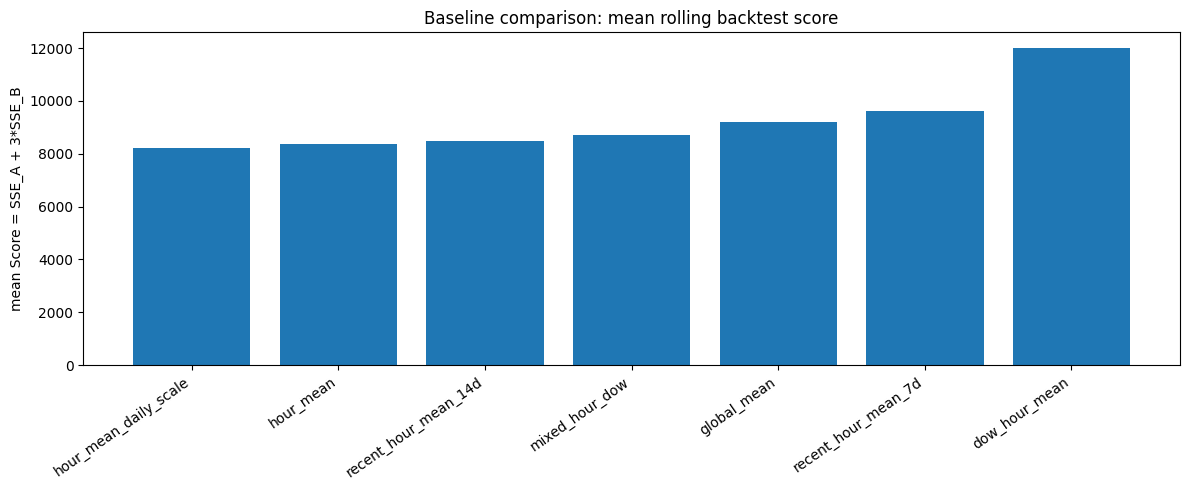

In [7]:
plt.figure(figsize=(12, 5))
plot_df = summary.reset_index().sort_values("mean_score")
plt.bar(plot_df["method"], plot_df["mean_score"])
plt.title("Baseline comparison: mean rolling backtest score")
plt.ylabel("mean Score = SSE_A + 3*SSE_B")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 6. 选择策略并预测验证期

默认选 rolling backtest 平均分最低的方法。如果方法差距很小，可以人工改 `SELECTED_METHOD`，选择更稳或更可解释的方法。

In [8]:
SELECTED_METHOD = summary.index[0]
print("selected method:", SELECTED_METHOD)

future_a = add_time_features(future_grid_a(), val_daily)
future_b = add_time_features(future_grid_b(), val_daily)

recent_days = 14 if str(SELECTED_METHOD).endswith("14d") else 7
future_a["prediction"] = predict_baseline(a_frame, future_a, "A", SELECTED_METHOD, recent_days=recent_days)
future_b["prediction"] = predict_baseline(b_frame, future_b, "B", SELECTED_METHOD, recent_days=recent_days)

# 评分用平方误差，提交如果允许小数，保留小数通常比强行四舍五入信息损失更小。
# 若官方要求整数，可以把下面两列改成 round 后 int。
future_a["prediction_rounded"] = future_a["prediction"].clip(lower=0).round().astype(int)
future_b["prediction_rounded"] = future_b["prediction"].clip(lower=0).round().astype(int)

display(future_a.head(12))
display(future_b.head(12))
print("A prediction summary")
display(future_a.groupby("region")["prediction"].describe())
print("B prediction summary")
display(future_b.groupby("task_key")["prediction"].describe())

selected method: hour_mean_daily_scale


,hour,region,task_key,date,hour_of_day,dayofweek,is_weekend,vessel_count,prediction,prediction_rounded
0,2018-01-25 00:00:00,core,core,2018-01-25,0,3,0,NaN,5.041667,5
1,2018-01-25 00:00:00,near,near,2018-01-25,0,3,0,NaN,2.500000,2
2,2018-01-25 00:00:00,outer,outer,2018-01-25,0,3,0,NaN,1.458333,1
3,2018-01-25 01:00:00,core,core,2018-01-25,1,3,0,NaN,2.041667,2
4,2018-01-25 01:00:00,near,near,2018-01-25,1,3,0,NaN,0.958333,1
5,2018-01-25 01:00:00,outer,outer,2018-01-25,1,3,0,NaN,1.500000,2
6,2018-01-25 02:00:00,core,core,2018-01-25,2,3,0,NaN,4.708333,5
7,2018-01-25 02:00:00,near,near,2018-01-25,2,3,0,NaN,1.875000,2
8,2018-01-25 02:00:00,outer,outer,2018-01-25,2,3,0,NaN,0.791667,1
9,2018-01-25 03:00:00,core,core,2018-01-25,3,3,0,NaN,8.125000,8


,hour,source_region,target_region,task_key,date,hour_of_day,dayofweek,is_weekend,vessel_count,prediction,prediction_rounded
0,2018-01-25 00:00:00,core,near,core->near,2018-01-25,0,3,0,NaN,0.000000,0
1,2018-01-25 00:00:00,core,outer,core->outer,2018-01-25,0,3,0,NaN,0.041667,0
2,2018-01-25 00:00:00,near,core,near->core,2018-01-25,0,3,0,NaN,1.083333,1
3,2018-01-25 00:00:00,near,outer,near->outer,2018-01-25,0,3,0,NaN,0.208333,0
4,2018-01-25 00:00:00,outer,core,outer->core,2018-01-25,0,3,0,NaN,0.041667,0
5,2018-01-25 00:00:00,outer,near,outer->near,2018-01-25,0,3,0,NaN,0.125000,0
6,2018-01-25 01:00:00,core,near,core->near,2018-01-25,1,3,0,NaN,0.375000,0
7,2018-01-25 01:00:00,core,outer,core->outer,2018-01-25,1,3,0,NaN,0.000000,0
8,2018-01-25 01:00:00,near,core,near->core,2018-01-25,1,3,0,NaN,0.166667,0
9,2018-01-25 01:00:00,near,outer,near->outer,2018-01-25,1,3,0,NaN,0.166667,0


A prediction summary


,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
core,168.0,5.918403,2.097365,2.041667,4.62500,6.083333,7.468750,10.250000
near,168.0,3.769097,1.609368,0.958333,2.56250,3.833333,4.718750,7.000000
outer,168.0,1.758681,0.716771,0.791667,1.21875,1.729167,2.166667,3.291667


B prediction summary


,count,mean,std,min,25%,50%,75%,max
task_key,,,,,,,,
core->near,168.0,1.083333,0.703762,0.000000,0.583333,0.895833,1.468750,2.458333
core->outer,168.0,0.215278,0.227838,0.000000,0.041667,0.145833,0.270833,1.000000
near->core,168.0,1.098958,0.489126,0.166667,0.697917,1.083333,1.583333,2.041667
near->outer,168.0,0.342014,0.280857,0.000000,0.125000,0.270833,0.510417,1.041667
outer->core,168.0,0.185764,0.130481,0.000000,0.114583,0.166667,0.250000,0.500000
outer->near,168.0,0.390625,0.291495,0.041667,0.125000,0.312500,0.635417,1.125000


## 7. 导出提交文件和中间标签

In [9]:
# 保存训练标签，方便后续模型复用。
a_label_path = RUN_OUTPUT_DIR / "a_train_labels.csv"
b_label_path = RUN_OUTPUT_DIR / "b_train_labels.csv"
a_frame.to_csv(a_label_path, index=False, encoding="utf-8-sig")
b_frame.to_csv(b_label_path, index=False, encoding="utf-8-sig")

# 提交文件：同时保留英文区域字段和中文区域字段，后续若官方模板明确字段名，可再调整。
a_submit = future_a[["hour", "region", "prediction", "prediction_rounded"]].copy()
a_submit["window_start"] = a_submit["hour"].dt.strftime("%Y-%m-%d %H:%M:%S")
a_submit["region_cn"] = a_submit["region"].map(REGION_CN)
a_submit = a_submit[["window_start", "region", "region_cn", "prediction", "prediction_rounded"]]

b_submit = future_b[["hour", "source_region", "target_region", "prediction", "prediction_rounded"]].copy()
b_submit["window_start"] = b_submit["hour"].dt.strftime("%Y-%m-%d %H:%M:%S")
b_submit["source_region_cn"] = b_submit["source_region"].map(REGION_CN)
b_submit["target_region_cn"] = b_submit["target_region"].map(REGION_CN)
b_submit = b_submit[["window_start", "source_region", "target_region", "source_region_cn", "target_region_cn", "prediction", "prediction_rounded"]]

a_submit_path = RUN_OUTPUT_DIR / "submit_A_baseline.csv"
b_submit_path = RUN_OUTPUT_DIR / "submit_B_baseline.csv"
a_submit.to_csv(a_submit_path, index=False, encoding="utf-8-sig")
b_submit.to_csv(b_submit_path, index=False, encoding="utf-8-sig")

print("saved:")
for p in [a_label_path, b_label_path, a_submit_path, b_submit_path]:
    print(p, p.stat().st_size, "bytes")

display(a_submit.head())
display(b_submit.head())

saved:
C:\Users\mandy\hl_Documents\2026CTS\outputs\20260709_110148\a_train_labels.csv 93979 bytes
C:\Users\mandy\hl_Documents\2026CTS\outputs\20260709_110148\b_train_labels.csv 227907 bytes
C:\Users\mandy\hl_Documents\2026CTS\outputs\20260709_110148\submit_A_baseline.csv 26405 bytes
C:\Users\mandy\hl_Documents\2026CTS\outputs\20260709_110148\submit_B_baseline.csv 69024 bytes


,window_start,region,region_cn,prediction,prediction_rounded
0,2018-01-25 00:00:00,core,核心区,5.041667,5
1,2018-01-25 00:00:00,near,近港区,2.500000,2
2,2018-01-25 00:00:00,outer,外围区,1.458333,1
3,2018-01-25 01:00:00,core,核心区,2.041667,2
4,2018-01-25 01:00:00,near,近港区,0.958333,1


,window_start,source_region,target_region,source_region_cn,target_region_cn,prediction,prediction_rounded
0,2018-01-25 00:00:00,core,near,核心区,近港区,0.000000,0
1,2018-01-25 00:00:00,core,outer,核心区,外围区,0.041667,0
2,2018-01-25 00:00:00,near,core,近港区,核心区,1.083333,1
3,2018-01-25 00:00:00,near,outer,近港区,外围区,0.208333,0
4,2018-01-25 00:00:00,outer,core,外围区,核心区,0.041667,0


## 8. 结论和下一步

这个 Notebook 的核心产物：

- rolling backtest 结果表 `bt`
- baseline 汇总表 `summary`
- A/B 训练标签 CSV
- A/B 验证期预测提交 CSV

下一步建议：

1. 对 A 和 B 分别选择方法，而不是强制共用一个 `SELECTED_METHOD`。
2. 为 `hour_mean_daily_scale` 搜索缩放指数，例如 `scale ** 0.0, 0.25, 0.5, 0.75, 1.0`。
3. 对 B 题单独尝试最近 7 天迁移均值，因为 B 权重高且迁移模式可能更依赖近期。
4. 根据官方提交模板，把导出字段名和区域命名精确调整。

## 9. 按官方模板 Zip 生成最终提交文件

`outputs/` 里有两个官方示例 zip：

- `提交结果1_区域活跃拖轮数量.zip`
- `提交结果2_圈层间拖轮迁移量.zip`

它们定义了最终提交字段、中文区域名、时间格式和行顺序。因此最终提交不要直接用前面的调试 CSV，而是读取模板，按模板行顺序填 `vessel_count`。

In [10]:
import zipfile


def read_template_from_zip(zip_name: str, csv_name: str) -> pd.DataFrame:
    with zipfile.ZipFile(TEMPLATE_DIR / zip_name) as z:
        with z.open(csv_name) as f:
            return pd.read_csv(f)


a_template = read_template_from_zip("提交结果1_区域活跃拖轮数量.zip", "提交结果1_区域活跃拖轮数量.csv")
b_template = read_template_from_zip("提交结果2_圈层间拖轮迁移量.zip", "提交结果2_圈层间拖轮迁移量.csv")

a_template["time_dt"] = pd.to_datetime(a_template["time_window"])
b_template["time_dt"] = pd.to_datetime(b_template["time_window"])

# A: 按模板 time_window + zone 填 prediction_rounded。
a_pred_for_template = a_submit.copy()
a_pred_for_template["time_dt"] = pd.to_datetime(a_pred_for_template["window_start"])
a_filled = a_template.drop(columns=["vessel_count"]).merge(
    a_pred_for_template[["time_dt", "region_cn", "prediction_rounded"]],
    left_on=["time_dt", "zone"],
    right_on=["time_dt", "region_cn"],
    how="left",
    validate="one_to_one",
)
if a_filled["prediction_rounded"].isna().any():
    raise ValueError("A 模板存在未匹配预测的行")

a_official = a_filled[["time_window", "zone"]].copy()
a_official["vessel_count"] = a_filled["prediction_rounded"].astype(int)

# B: 按模板 time_window + source_zone + target_zone 填 prediction_rounded。
b_pred_for_template = b_submit.copy()
b_pred_for_template["time_dt"] = pd.to_datetime(b_pred_for_template["window_start"])
b_filled = b_template.drop(columns=["vessel_count"]).merge(
    b_pred_for_template[["time_dt", "source_region_cn", "target_region_cn", "prediction_rounded"]],
    left_on=["time_dt", "source_zone", "target_zone"],
    right_on=["time_dt", "source_region_cn", "target_region_cn"],
    how="left",
    validate="one_to_one",
)
if b_filled["prediction_rounded"].isna().any():
    raise ValueError("B 模板存在未匹配预测的行")

b_official = b_filled[["time_window", "source_zone", "target_zone"]].copy()
b_official["vessel_count"] = b_filled["prediction_rounded"].astype(int)

# 保存为 CSV 和 zip。zip 内部文件名保持和官方模板一致。
a_official_csv = RUN_OUTPUT_DIR / "提交结果1_区域活跃拖轮数量.csv"
b_official_csv = RUN_OUTPUT_DIR / "提交结果2_圈层间拖轮迁移量.csv"
a_official_zip = RUN_OUTPUT_DIR / "提交结果1_区域活跃拖轮数量.zip"
b_official_zip = RUN_OUTPUT_DIR / "提交结果2_圈层间拖轮迁移量.zip"

a_official.to_csv(a_official_csv, index=False, encoding="utf-8-sig")
b_official.to_csv(b_official_csv, index=False, encoding="utf-8-sig")

for csv_path, zip_path, arcname in [
    (a_official_csv, a_official_zip, "提交结果1_区域活跃拖轮数量.csv"),
    (b_official_csv, b_official_zip, "提交结果2_圈层间拖轮迁移量.csv"),
]:
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
        z.write(csv_path, arcname=arcname)

print("A rows:", len(a_official), "->", a_official_zip)
print("B rows:", len(b_official), "->", b_official_zip)
display(a_official.head())
display(b_official.head())

A rows: 504 -> C:\Users\mandy\hl_Documents\2026CTS\outputs\20260709_110148\提交结果1_区域活跃拖轮数量.zip
B rows: 1008 -> C:\Users\mandy\hl_Documents\2026CTS\outputs\20260709_110148\提交结果2_圈层间拖轮迁移量.zip


,time_window,zone,vessel_count
0,1/25/2018 0:00,核心区,5
1,1/25/2018 0:00,近港区,2
2,1/25/2018 0:00,外围区,1
3,1/25/2018 1:00,核心区,2
4,1/25/2018 1:00,近港区,1


,time_window,source_zone,target_zone,vessel_count
0,1/25/2018 0:00,核心区,近港区,0
1,1/25/2018 0:00,核心区,外围区,0
2,1/25/2018 0:00,近港区,核心区,1
3,1/25/2018 0:00,近港区,外围区,0
4,1/25/2018 0:00,外围区,核心区,0
